# 📈 Chương 4 — Dataset 2: Google Stock Price — Conv1D + LSTM
## Kỹ thuật: Conv1D (trích xuất đặc trưng cục bộ) + LSTM (xu hướng dài hạn)

**Pipeline:** EDA → Technical Indicators → Sliding Window → Conv1D+LSTM → Train → Forecast

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import glob, os, warnings

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

DATA_DIR   = '../data/google_stock'
SAVE_DIR   = '../results/google_stock'
os.makedirs(SAVE_DIR, exist_ok=True)

LOOK_BACK  = 60   # 60 ngày
EPOCHS     = 50
BATCH_SIZE = 32

print(f'TF: {tf.__version__}')

I0000 00:00:1780118754.675442 1929323 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780118754.711322 1929323 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF: 2.21.0


I0000 00:00:1780118755.532097 1929323 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 📂 1. Load Data

In [2]:
csv_files = glob.glob(f'{DATA_DIR}/**/*.csv', recursive=True) + glob.glob(f'{DATA_DIR}/*.csv')
print('Found:', csv_files)
df = pd.read_csv(csv_files[0])
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(20)

Found: ['../data/google_stock/GOOG.csv', '../data/google_stock/GOOG.csv']
Shape: (5000, 7)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.67,50.47,49.02,50.00,50.00,11426684
1,2004-08-20,50.16,50.74,49.48,50.47,50.47,29767144
2,2004-08-23,50.32,51.66,49.67,50.36,50.36,7504465
3,2004-08-24,50.76,51.59,50.03,50.97,50.97,31771685
4,2004-08-25,52.15,53.04,50.84,52.41,52.41,44407726
5,2004-08-26,52.36,52.48,51.79,52.21,52.21,7132062
6,2004-08-27,52.17,52.61,51.63,52.01,52.01,3288143
7,2004-08-30,53.88,54.94,53.13,53.54,53.54,16184743
8,2004-08-31,54.21,54.89,53.23,54.30,54.30,48682994
9,2004-09-01,53.41,55.40,53.09,53.87,53.87,33357284


In [3]:
# Detect date and price columns
date_col  = [c for c in df.columns if 'date' in c.lower()]
close_col = [c for c in df.columns if 'close' in c.lower() or 'price' in c.lower()]
open_col  = [c for c in df.columns if 'open'  in c.lower()]
high_col  = [c for c in df.columns if 'high'  in c.lower()]
low_col   = [c for c in df.columns if 'low'   in c.lower()]
vol_col   = [c for c in df.columns if 'vol'   in c.lower()]

close_col = close_col[0] if close_col else df.columns[1]
print(f'Target (Close): {close_col}')

if date_col:
    df[date_col[0]] = pd.to_datetime(df[date_col[0]])
    df = df.sort_values(date_col[0]).reset_index(drop=True)

# Clean numeric columns
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(',','').str.replace('$','')
        try: df[col] = pd.to_numeric(df[col])
        except: pass

df = df.dropna(subset=[close_col])
print(f'Final shape: {df.shape}')

Target (Close): Close
Final shape: (5000, 7)


## 📊 2. EDA + Technical Indicators

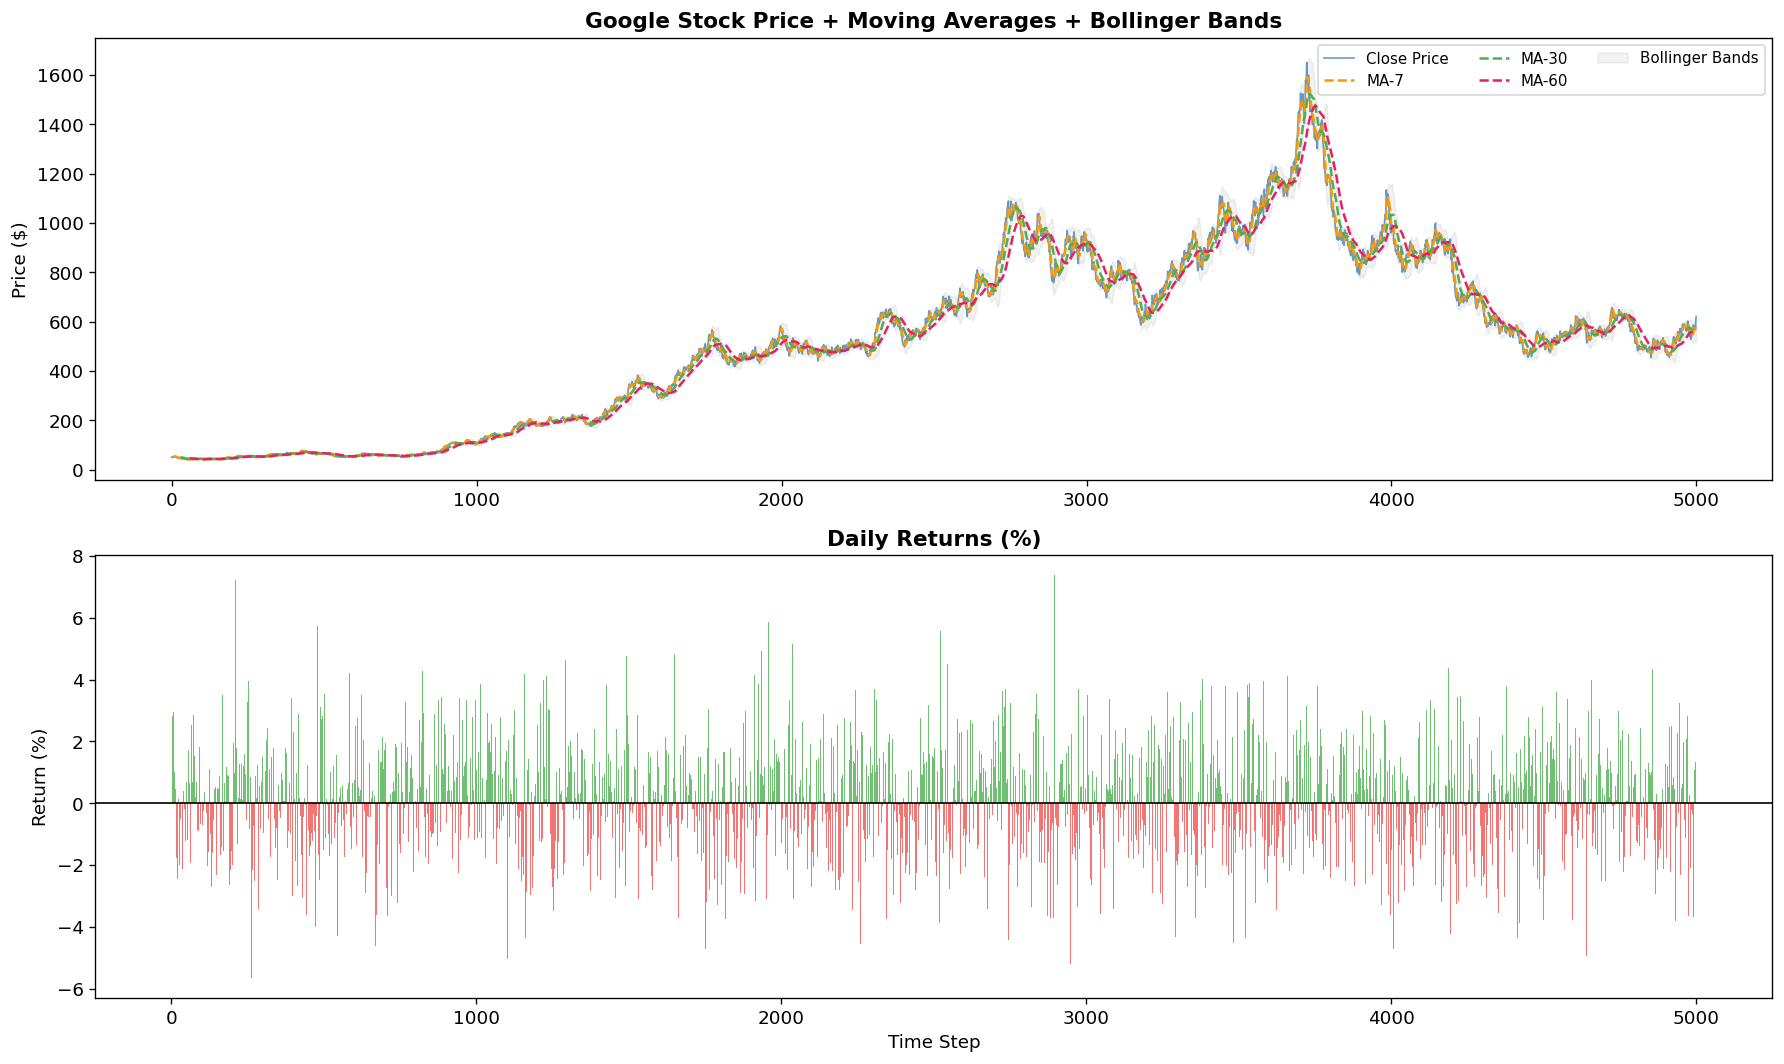

Price range: $40.88 — $1650.61
Mean return: 0.0665%, Std: 1.7947%


In [4]:
prices = df[close_col].values.astype(float)

# Compute Moving Averages
ma_7   = pd.Series(prices).rolling(7).mean().values
ma_30  = pd.Series(prices).rolling(30).mean().values
ma_60  = pd.Series(prices).rolling(60).mean().values

# Bollinger Bands
roll_mean = pd.Series(prices).rolling(20).mean()
roll_std  = pd.Series(prices).rolling(20).std()
bb_upper  = (roll_mean + 2 * roll_std).values
bb_lower  = (roll_mean - 2 * roll_std).values

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Price + Moving Averages
axes[0].plot(prices, color='steelblue', lw=1, alpha=0.8, label='Close Price')
axes[0].plot(ma_7,  color='#FF9800', lw=1.5, linestyle='--', label='MA-7')
axes[0].plot(ma_30, color='#4CAF50', lw=1.5, linestyle='--', label='MA-30')
axes[0].plot(ma_60, color='#E91E63', lw=1.5, linestyle='--', label='MA-60')
axes[0].fill_between(range(len(prices)), bb_upper, bb_lower, alpha=0.1, color='gray', label='Bollinger Bands')
axes[0].set_title('Google Stock Price + Moving Averages + Bollinger Bands')
axes[0].set_ylabel('Price ($)')
axes[0].legend(ncol=3, fontsize=9)

# Daily returns
returns = pd.Series(prices).pct_change().values * 100
axes[1].bar(range(len(returns)), returns, color=np.where(returns>=0, '#4CAF50', '#EF5350'),
            width=1, alpha=0.8)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Daily Returns (%)')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Return (%)')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_stock_eda.png', bbox_inches='tight')
plt.show()

print(f'Price range: ${prices.min():.2f} — ${prices.max():.2f}')
print(f'Mean return: {np.nanmean(returns):.4f}%, Std: {np.nanstd(returns):.4f}%')

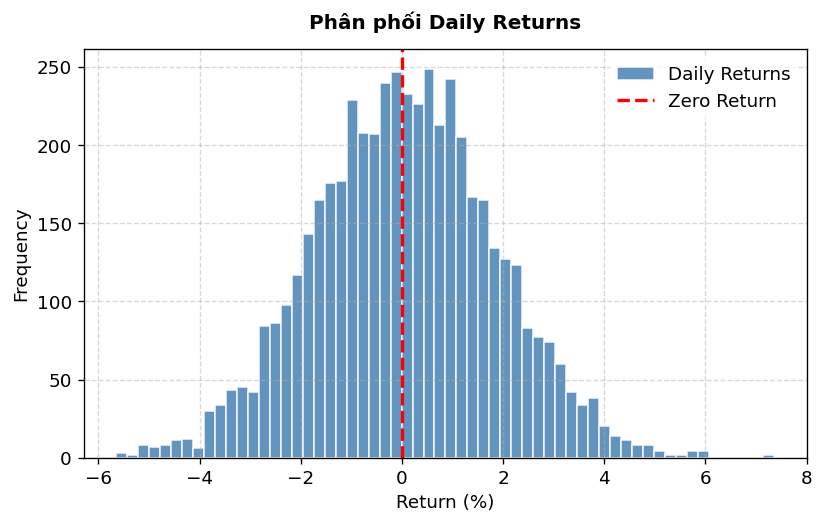

In [5]:
# 1. Daily Returns Distribution
plt.figure(figsize=(7, 4.5))

plt.hist(returns[~np.isnan(returns)], bins=60, color='steelblue',
         edgecolor='white', alpha=0.85, label='Daily Returns')
plt.axvline(0, color='red', linestyle='--', lw=2, label='Zero Return')

plt.title('Phân phối Daily Returns', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Return (%)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Lưu biểu đồ phân phối lợi nhuận hàng ngày
plt.savefig(f'{SAVE_DIR}/02_a_daily_returns_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

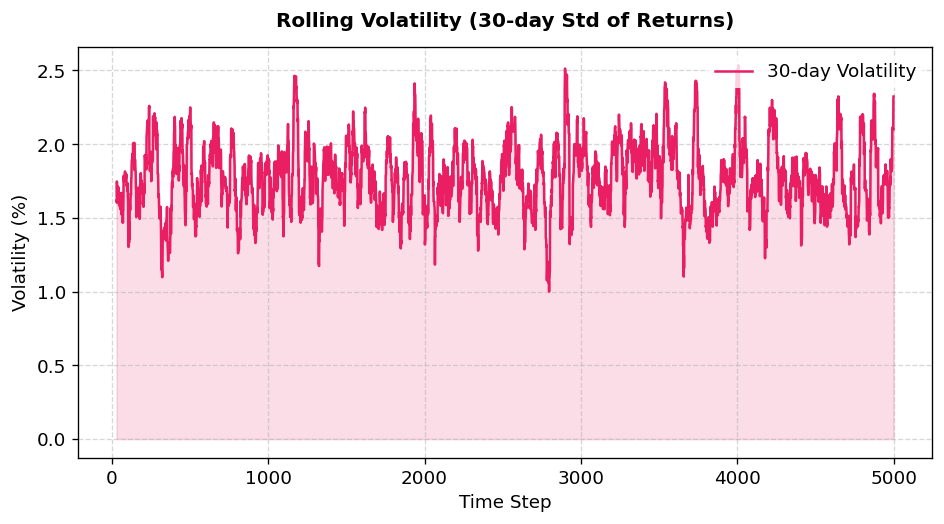

In [6]:
# 2. Rolling Volatility (30-day)
plt.figure(figsize=(8, 4.5))

vol = pd.Series(returns).rolling(30).std().values
plt.plot(vol, color='#E91E63', lw=1.5, label='30-day Volatility')
plt.fill_between(range(len(vol)), vol, alpha=0.15, color='#E91E63')

plt.title('Rolling Volatility (30-day Std of Returns)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Time Step')
plt.ylabel('Volatility (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Lưu biểu đồ độ biến động lăn
plt.savefig(f'{SAVE_DIR}/02_b_rolling_volatility.png', dpi=120, bbox_inches='tight')
plt.show()

## ⚙️ 3. Preprocessing — Sliding Window

In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(prices.reshape(-1, 1)).flatten()

def create_dataset(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i+look_back])
        y.append(data[i+look_back])
    return np.array(X), np.array(y)

X, y = create_dataset(prices_scaled, LOOK_BACK)
X = X.reshape(X.shape[0], X.shape[1], 1)  # (samples, timesteps, features)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'X shape: {X.shape}  -> (samples, look_back={LOOK_BACK}, 1)')
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

X shape: (4940, 60, 1)  -> (samples, look_back=60, 1)
Train: (3952, 60, 1), Test: (988, 60, 1)


## 🏗️ 4. Conv1D + LSTM Model

In [8]:
model = models.Sequential([
    # Conv1D: trích xuất đặc trưng cục bộ (local patterns)
    layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                  input_shape=(LOOK_BACK, 1), padding='same', name='conv1d_1'),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu',
                  padding='same', name='conv1d_2'),
    layers.MaxPooling1D(pool_size=2),
    layers.Dropout(0.2),
    layers.LSTM(100, return_sequences=True, name='lstm_1'),
    layers.Dropout(0.3),
    layers.LSTM(50, name='lstm_2'),
    layers.Dropout(0.3),
    layers.Dense(25, activation='relu'),
    layers.Dense(1, name='forecast')
], name='Conv1D_LSTM_StockPrice')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse', metrics=['mae'])
model.summary()

I0000 00:00:1780118767.343077 1929323 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 41762 MB memory:  -> device: 0, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1780118767.345739 1929323 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46629 MB memory:  -> device: 1, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:41:00.0, compute capability: 8.9
I0000 00:00:1780118767.347870 1929323 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 5500 MB memory:  -> device: 2, name: NVIDIA RTX 5880 Ada Generation, pci bus id: 0000:83:00.0, compute capability: 8.9


Model: "Conv1D_LSTM_StockPrice"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 60, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 60, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 100)        │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,109 (430.11 KB)

 Trainable params: 110,109 (430.11 KB)

 Non-trainable params: 0 (0.00 B)

## 🚀 5. Training

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ],
    verbose=1
)

Epoch 1/50


I0000 00:00:1780118770.758507 1930455 cuda_dnn.cc:461] Loaded cuDNN version 92101


112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0062 - mae: 0.0471 - val_loss: 0.0028 - val_mae: 0.0390 - learning_rate: 0.0010
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0015 - mae: 0.0254 - val_loss: 0.0021 - val_mae: 0.0368 - learning_rate: 0.0010
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0012 - mae: 0.0233 - val_loss: 0.0028 - val_mae: 0.0388 - learning_rate: 0.0010
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0010 - mae: 0.0223 - val_loss: 0.0054 - val_mae: 0.0581 - learning_rate: 0.0010
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0010 - mae: 0.0216 - val_loss: 0.0016 - val_mae: 0.0309 - learning_rate: 0.0010
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 8.7566e-04 - mae: 0.0204 - val_loss: 0.0044 - val_mae: 0.0530 - learning_rate: 0.0010
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 7.0677e-04 - mae: 0.0185 - val_loss: 0.0044 - val_mae: 0.0542 - learning_rate: 0.0010
Ep

## 📈 6. Evaluation & Forecast Visualization

In [10]:
# Predict and inverse transform
y_pred_scaled = model.predict(X_test, verbose=0).flatten()
y_pred_orig   = scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).flatten()
y_test_orig   = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

train_pred_s  = model.predict(X_train, verbose=0).flatten()
train_pred    = scaler.inverse_transform(train_pred_s.reshape(-1,1)).flatten()
y_train_orig  = scaler.inverse_transform(y_train.reshape(-1,1)).flatten()

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae  = mean_absolute_error(y_test_orig, y_pred_orig)
r2   = r2_score(y_test_orig, y_pred_orig)

print(f'RMSE : ${rmse:.4f}')
print(f'MAE  : ${mae:.4f}')
print(f'R²   : {r2:.4f}')

RMSE : $35.9275
MAE  : $29.3849
R²   : 0.9342


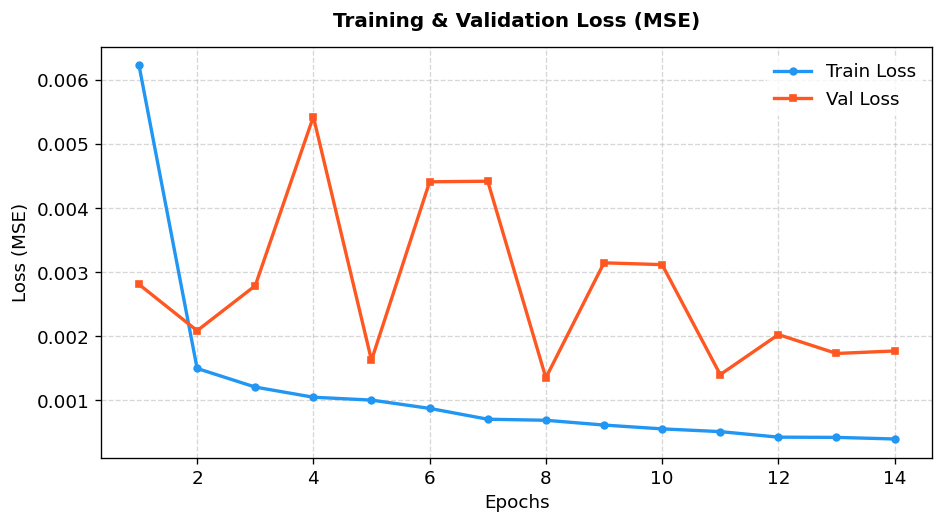

In [11]:
# 1. Training History - Loss
plt.figure(figsize=(8, 4.5))

eps = range(1, len(history.history['loss']) + 1)
plt.plot(eps, history.history['loss'], 'o-', color='#2196F3', lw=2, ms=4, label='Train Loss')
plt.plot(eps, history.history['val_loss'], 's-', color='#FF5722', lw=2, ms=4, label='Val Loss')

plt.title('Training & Validation Loss (MSE)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Lưu biểu đồ lịch sử huấn luyện
plt.savefig(f'{SAVE_DIR}/03_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

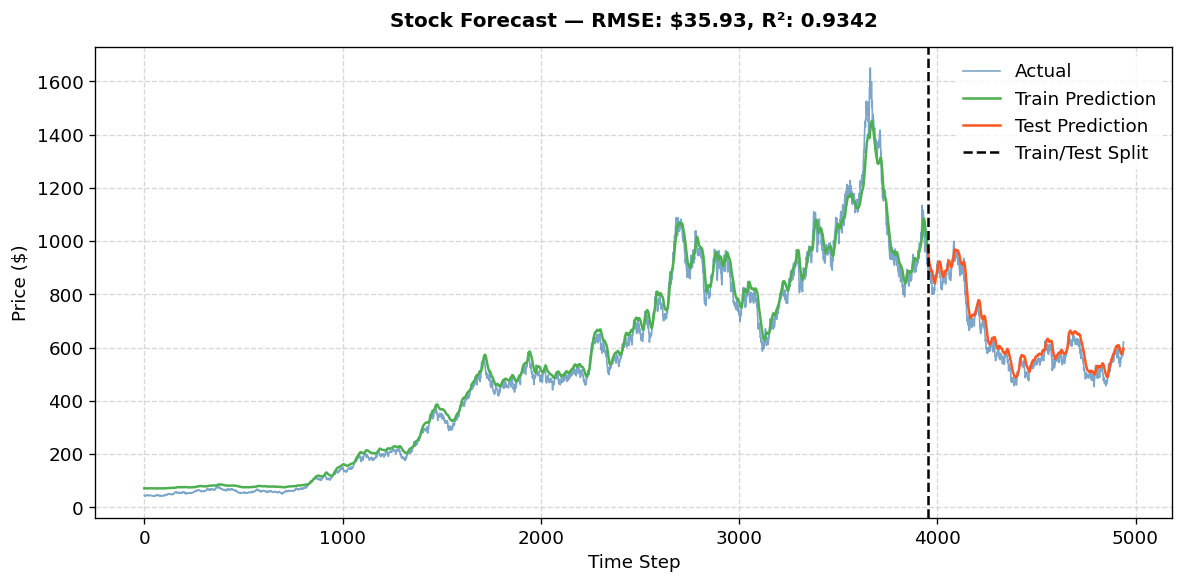

In [12]:
# 2. Full Forecast View
plt.figure(figsize=(10, 5))

full_prices = prices[LOOK_BACK:]
train_line = np.full(len(full_prices), np.nan)
test_line = np.full(len(full_prices), np.nan)
train_line[:split] = train_pred
test_line[split:] = y_pred_orig

plt.plot(full_prices, color='steelblue', lw=1, alpha=0.7, label='Actual')
plt.plot(train_line, color='#4CAF50', lw=1.5, label='Train Prediction')
plt.plot(test_line, color='#FF5722', lw=1.5, label='Test Prediction')
plt.axvline(split, color='black', linestyle='--', lw=1.5, label='Train/Test Split')

plt.title(f'Stock Forecast — RMSE: ${rmse:.2f}, R²: {r2:.4f}', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Time Step')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Lưu biểu đồ dự báo toàn bộ chuỗi
plt.savefig(f'{SAVE_DIR}/04_forecast_full.png', dpi=120, bbox_inches='tight')
plt.show()

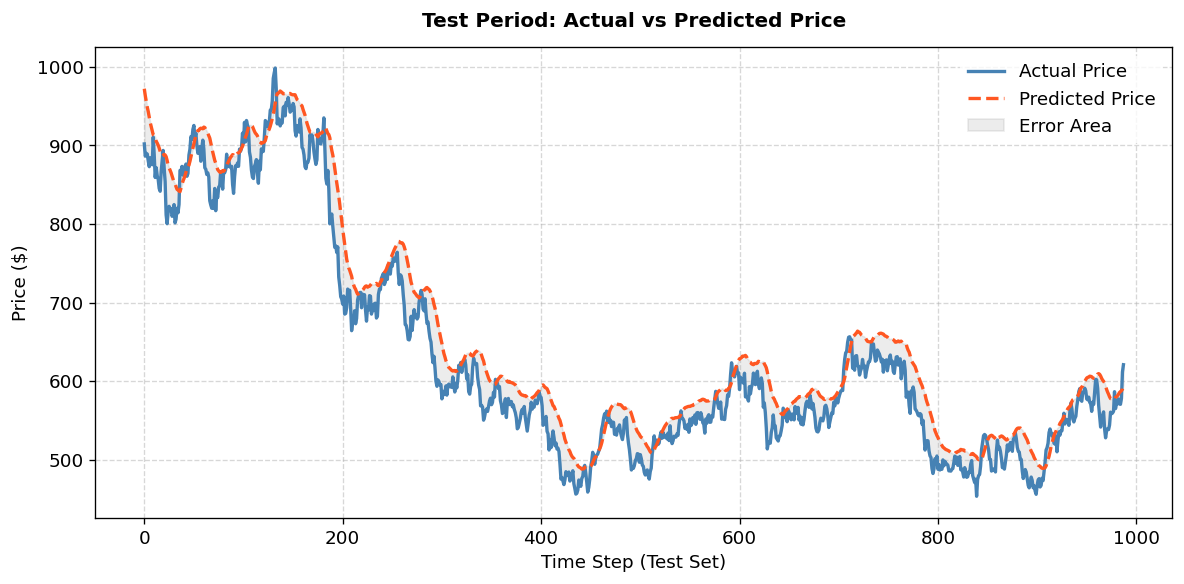

In [13]:
# 3. Zoom into Test Period
plt.figure(figsize=(10, 5))

plt.plot(y_test_orig, color='steelblue', lw=2, label='Actual Price')
plt.plot(y_pred_orig, color='#FF5722', lw=2, linestyle='--', label='Predicted Price')
plt.fill_between(range(len(y_test_orig)), y_test_orig, y_pred_orig, 
                 alpha=0.15, color='gray', label='Error Area')

plt.title('Test Period: Actual vs Predicted Price', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Time Step (Test Set)')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Lưu biểu đồ so sánh chi tiết trên tập test
plt.savefig(f'{SAVE_DIR}/05_forecast_test.png', dpi=120, bbox_inches='tight')
plt.show()

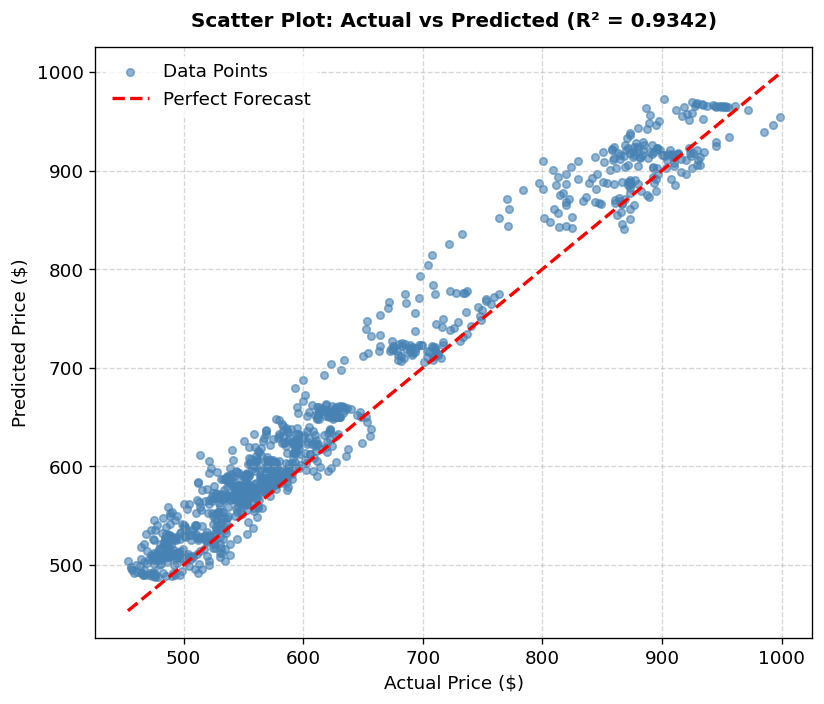

In [14]:
# 4. Scatter Plot (Actual vs Predicted)
plt.figure(figsize=(7, 6))

plt.scatter(y_test_orig, y_pred_orig, alpha=0.6, s=20, color='steelblue', label='Data Points')
mn, mx = min(y_test_orig.min(), y_pred_orig.min()), max(y_test_orig.max(), y_pred_orig.max())
plt.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Forecast')

plt.title(f'Scatter Plot: Actual vs Predicted (R² = {r2:.4f})', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Lưu biểu đồ phân tán tương quan
plt.savefig(f'{SAVE_DIR}/06_forecast_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Google Stock Price — Conv1D + LSTM\n' + '='*50 + '\n')
    f.write(f'LOOK_BACK : {LOOK_BACK} days\n')
    f.write(f'Params    : {model.count_params():,}\n\n')
    f.write(f'Test RMSE : ${rmse:.4f}\n')
    f.write(f'Test MAE  : ${mae:.4f}\n')
    f.write(f'Test R²   : {r2:.4f}\n')

print('✅ Google Stock Conv1D+LSTM Done! Saved to', SAVE_DIR)

✅ Google Stock Conv1D+LSTM Done! Saved to ../results/google_stock
